<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Task 1 (50 points):
This task involves training existing models. Download the
character level RNN at https://github.com/karpathy/char-rnn
You are required to read the documentation provided in this repository and experiment with the RNN model. This is a legacy repository; therefore, one task would be to research and use a recent version. Train the model on ‘tiny Shakespeare’ dataset available at the same location.
Create outputs of the model after training for i) 5 epochs ii) 50 epochs and iii) 500 epochs. What significant difference do you observe between the 3 outputs? Explain. Repeat the experiment with the LSTM model provided in the repository. Explain the differences and/or similarities between the results of both models.

### Answer
The code and results are listed below. The results from training both RNN and LSTM models across 5, 50, and 500 epochs reveal differences in their learning capabilities and the coherence of generated text.

Initially, both models start with incoherent outputs due to insufficient training, with words being a random mixture of characters rather than structured language. However, the LSTM already shows a slight edge in structure early on. By 50 epochs, the RNN begins to create somewhat understandable text but still significantly lags behind the LSTM, which produces more fluent and syntactically correct sequences. This improvement in LSTM outcomes demonstrates its ability to leverage its gating mechanisms to manage information flow better, allowing it to maintain long-term dependencies essential for meaningful sentence construction.

By 500 epochs, the LSTM further solidifies its superiority with coherent and structured dialogue, reflecting its capacity to learn complex patterns within the data effectively. The RNN improves with more training but struggles with inconsistencies, highlighting its limitation in retaining long-term contextual information due to vanishing gradient issues inherent to its architecture. The lower loss values and higher textual coherence of the LSTM underscore its adeptness at handling sequential data, validating the architectural enhancements that make it favorable for text generation tasks. These experiments reinforce the well-established preference for LSTMs in tasks requiring processing of long sequences, like language modeling and text generation.

In [16]:
import urllib.request

# Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
file_path = "tinyshakespeare.txt"
urllib.request.urlretrieve(url, file_path)

with open(file_path, "r") as f:
    text = f.read()

print("Dataset Sample:\n")
print(text[:1000])

# Character-to-index mapping
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

# Encode the entire dataset
encoded_text = np.array([char_to_idx[ch] for ch in text])

print(f"Unique characters: {''.join(chars)}")


Dataset Sample:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thir

In [1]:
!nvidia-smi

Tue Feb 25 04:55:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.nn.functional as F

# use gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size, device=device)

# train
def train(rnn, encoded_text, vocab_size, seq_length, num_epochs, learning_rate, batch_size):
    optimizer = optim.Adam(rnn.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Move the model to GPU
    rnn.to(device)

    num_batches = (len(encoded_text) - 1) // (batch_size * seq_length)

    for epoch in range(num_epochs):
        hidden = rnn.init_hidden(batch_size)
        total_loss = 0

        for batch in range(num_batches):
            # Calculate start indices for the batch
            start_idx = batch * batch_size * seq_length
            end_idx = start_idx + seq_length * batch_size
            if end_idx >= len(encoded_text):
                break

            # Prepare batch data (inputs and targets)
            batch_inputs = []
            batch_targets = []
            for b in range(batch_size):
                start = start_idx + (b * seq_length)
                batch_inputs.append(encoded_text[start:start + seq_length])
                batch_targets.append(encoded_text[start + 1:start + seq_length + 1])

            inputs = torch.eye(vocab_size)[np.array(batch_inputs)].to(device)
            targets = torch.tensor(np.array(batch_targets), device=device)

            if isinstance(hidden, tuple):  # For LSTMs
                hidden = tuple([each.detach() for each in hidden])
            else:  # For simple RNNs
                hidden = hidden.detach()

            optimizer.zero_grad()
            output, hidden = rnn(inputs, hidden)
            loss = criterion(output.view(-1, vocab_size), targets.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss/num_batches:.4f}')

def predict(model, char, h=None, top_k=None):
    char_to_idx, idx_to_char = model.char_to_idx, model.idx_to_char
    x = np.array([[char_to_idx[char]]])
    x = torch.nn.functional.one_hot(torch.tensor(x), num_classes=len(char_to_idx)).float()
    inputs = x.to(device)

    if h is None:
        h = model.init_hidden(1)
    # For LSTM, detach both hidden and cell states, for RNN just detach hidden state
    if isinstance(h, tuple):  # LSTM
        h = tuple([each.data for each in h])
    else:  # RNN
        h = h.data

    out, h = model(inputs, h)

    p = F.softmax(out, dim=-1).data
    p = p.cpu()

    if top_k is None:
        top_ch = np.arange(len(char_to_idx))
    else:
        p, top_ch = p.topk(top_k)
        top_ch = top_ch.numpy().squeeze()

    p = p.numpy().squeeze()
    char = np.random.choice(top_ch, p=p/p.sum())

    return idx_to_char[char], h

# Function to generate text
def generate_text(model, length, starting_text='The', top_k=None):
    model.eval()
    chars = [ch for ch in starting_text]
    char_to_idx, idx_to_char = model.char_to_idx, model.idx_to_char
    h = model.init_hidden(1)

    for ch in starting_text:
        char, h = predict(model, ch, h, top_k=top_k)
        chars.append(char)

    for ii in range(length):
        char, h = predict(model, chars[-1], h, top_k=top_k)
        chars.append(char)

    return ''.join(chars)

def train_and_generate(model, data, vocab_size, seq_length, learning_rate, batch_size, num_epochs, start_text='The', sample_length=200):
    # Train
    train(model, data, vocab_size, seq_length, num_epochs, learning_rate, batch_size)

    # Generate text after training
    print(f"\nGenerated text after {num_epochs} epochs:")
    print(generate_text(model, sample_length, starting_text=start_text, top_k=5))

if __name__ == "__main__":
    # load data
    with open("tinyshakespeare.txt", "r") as f:
      text = f.read()
    chars = sorted(list(set(text)))
    # mapping
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}
    vocab_size = len(chars)
    # encode
    encoded_text = np.array([char_to_idx[ch] for ch in text])

    # model init
    hidden_size = 128
    vocab_size = len(chars)
    seq_length = 100
    num_epochs = 5
    batch_size = 64
    learning_rate = 0.005

    # testing with different epoch settings

    print(f"\nTraining RNN with 5 epochs:")
    model = CharRNN(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
    model.char_to_idx = char_to_idx
    model.idx_to_char = idx_to_char
    model.chars = chars
    model.to(device)
    train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=5, start_text='The')


Using device: cuda

Training RNN with 5 epochs:
Epoch 1/5, Loss: 2.6663
Epoch 2/5, Loss: 2.1414
Epoch 3/5, Loss: 1.9927
Epoch 4/5, Loss: 1.9047
Epoch 5/5, Loss: 1.8466

Generated text after 5 epochs:
TheAon for thou deet of tay asle the world the born and all thin thou trence this battle.

Preas it not where inte on the much an hath thou are as and thou are a tranger a pristed than the bence. Whee in wi


In [19]:
# RNN 50 epochs
print(f"\nTraining RNN with 50 epochs:")
model = CharRNN(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
model.char_to_idx = char_to_idx
model.idx_to_char = idx_to_char
model.chars = chars
model.to(device)
train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=50, start_text='The')


Training RNN with 50 epochs:
Epoch 1/50, Loss: 2.6091
Epoch 2/50, Loss: 2.1209
Epoch 3/50, Loss: 1.9807
Epoch 4/50, Loss: 1.8959
Epoch 5/50, Loss: 1.8391
Epoch 6/50, Loss: 1.7969
Epoch 7/50, Loss: 1.7647
Epoch 8/50, Loss: 1.7399
Epoch 9/50, Loss: 1.7206
Epoch 10/50, Loss: 1.7046
Epoch 11/50, Loss: 1.6907
Epoch 12/50, Loss: 1.6788
Epoch 13/50, Loss: 1.6689
Epoch 14/50, Loss: 1.6605
Epoch 15/50, Loss: 1.6531
Epoch 16/50, Loss: 1.6466
Epoch 17/50, Loss: 1.6409
Epoch 18/50, Loss: 1.6357
Epoch 19/50, Loss: 1.6309
Epoch 20/50, Loss: 1.6264
Epoch 21/50, Loss: 1.6222
Epoch 22/50, Loss: 1.6184
Epoch 23/50, Loss: 1.6148
Epoch 24/50, Loss: 1.6113
Epoch 25/50, Loss: 1.6081
Epoch 26/50, Loss: 1.6049
Epoch 27/50, Loss: 1.6021
Epoch 28/50, Loss: 1.5994
Epoch 29/50, Loss: 1.5968
Epoch 30/50, Loss: 1.5950
Epoch 31/50, Loss: 1.5930
Epoch 32/50, Loss: 1.5914
Epoch 33/50, Loss: 1.5901
Epoch 34/50, Loss: 1.5885
Epoch 35/50, Loss: 1.5863
Epoch 36/50, Loss: 1.5848
Epoch 37/50, Loss: 1.5827
Epoch 38/50, Loss

In [21]:
print(f"\nTraining RNN with 500 epochs:")
model = CharRNN(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
model.char_to_idx = char_to_idx
model.idx_to_char = idx_to_char
model.chars = chars
model.to(device)
train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=500, start_text='The')



Training RNN with 500 epochs:
Epoch 1/500, Loss: 2.6962
Epoch 2/500, Loss: 2.1548
Epoch 3/500, Loss: 2.0118
Epoch 4/500, Loss: 1.9209
Epoch 5/500, Loss: 1.8592
Epoch 6/500, Loss: 1.8131
Epoch 7/500, Loss: 1.7785
Epoch 8/500, Loss: 1.7521
Epoch 9/500, Loss: 1.7319
Epoch 10/500, Loss: 1.7150
Epoch 11/500, Loss: 1.7002
Epoch 12/500, Loss: 1.6872
Epoch 13/500, Loss: 1.6761
Epoch 14/500, Loss: 1.6662
Epoch 15/500, Loss: 1.6576
Epoch 16/500, Loss: 1.6501
Epoch 17/500, Loss: 1.6435
Epoch 18/500, Loss: 1.6375
Epoch 19/500, Loss: 1.6321
Epoch 20/500, Loss: 1.6271
Epoch 21/500, Loss: 1.6226
Epoch 22/500, Loss: 1.6185
Epoch 23/500, Loss: 1.6145
Epoch 24/500, Loss: 1.6108
Epoch 25/500, Loss: 1.6074
Epoch 26/500, Loss: 1.6042
Epoch 27/500, Loss: 1.6014
Epoch 28/500, Loss: 1.5985
Epoch 29/500, Loss: 1.5963
Epoch 30/500, Loss: 1.5939
Epoch 31/500, Loss: 1.5922
Epoch 32/500, Loss: 1.5906
Epoch 33/500, Loss: 1.5887
Epoch 34/500, Loss: 1.5872
Epoch 35/500, Loss: 1.5855
Epoch 36/500, Loss: 1.5840
Epoch 

In [27]:

# LSTM model
class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        # LSTM has two hidden states: hidden state (h0) and cell state (c0)
        h0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return (h0, c0)

print(f"\nTraining LSTM with 5 epochs:")
model = CharLSTM(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
model.char_to_idx = char_to_idx
model.idx_to_char = idx_to_char
model.chars = chars
model.to(device)
train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=5, start_text='The')


Training LSTM with 5 epochs:
Epoch 1/5, Loss: 2.7091
Epoch 2/5, Loss: 2.1185
Epoch 3/5, Loss: 1.9582
Epoch 4/5, Loss: 1.8558
Epoch 5/5, Loss: 1.7832

Generated text after 5 epochs:
TheAere a duttent thee, that he shall
We can the read, shall the dearn thy suching, we come
That why wear sir as a dong the dauth
Beant a mence and then all be thy bring in the daughter son a blown the can 


In [28]:
print(f"\nTraining LSTM with 50 epochs:")
model = CharLSTM(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
model.char_to_idx = char_to_idx
model.idx_to_char = idx_to_char
model.chars = chars
model.to(device)
train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=50, start_text='The')


Training LSTM with 50 epochs:
Epoch 1/50, Loss: 2.7150
Epoch 2/50, Loss: 2.1419
Epoch 3/50, Loss: 1.9887
Epoch 4/50, Loss: 1.8878
Epoch 5/50, Loss: 1.8088
Epoch 6/50, Loss: 1.7472
Epoch 7/50, Loss: 1.6998
Epoch 8/50, Loss: 1.6619
Epoch 9/50, Loss: 1.6305
Epoch 10/50, Loss: 1.6041
Epoch 11/50, Loss: 1.5820
Epoch 12/50, Loss: 1.5638
Epoch 13/50, Loss: 1.5471
Epoch 14/50, Loss: 1.5324
Epoch 15/50, Loss: 1.5197
Epoch 16/50, Loss: 1.5093
Epoch 17/50, Loss: 1.4997
Epoch 18/50, Loss: 1.4908
Epoch 19/50, Loss: 1.4829
Epoch 20/50, Loss: 1.4754
Epoch 21/50, Loss: 1.4684
Epoch 22/50, Loss: 1.4622
Epoch 23/50, Loss: 1.4571
Epoch 24/50, Loss: 1.4519
Epoch 25/50, Loss: 1.4470
Epoch 26/50, Loss: 1.4425
Epoch 27/50, Loss: 1.4385
Epoch 28/50, Loss: 1.4348
Epoch 29/50, Loss: 1.4312
Epoch 30/50, Loss: 1.4280
Epoch 31/50, Loss: 1.4248
Epoch 32/50, Loss: 1.4219
Epoch 33/50, Loss: 1.4197
Epoch 34/50, Loss: 1.4174
Epoch 35/50, Loss: 1.4142
Epoch 36/50, Loss: 1.4112
Epoch 37/50, Loss: 1.4095
Epoch 38/50, Los

In [29]:
print(f"\nTraining LSTM with 500 epochs:")
model = CharLSTM(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)
model.char_to_idx = char_to_idx
model.idx_to_char = idx_to_char
model.chars = chars
model.to(device)
train_and_generate(model, encoded_text, vocab_size, seq_length, learning_rate, batch_size, num_epochs=500, start_text='The')


Training LSTM with 500 epochs:
Epoch 1/500, Loss: 2.7125
Epoch 2/500, Loss: 2.1315
Epoch 3/500, Loss: 1.9733
Epoch 4/500, Loss: 1.8731
Epoch 5/500, Loss: 1.7998
Epoch 6/500, Loss: 1.7427
Epoch 7/500, Loss: 1.6949
Epoch 8/500, Loss: 1.6557
Epoch 9/500, Loss: 1.6234
Epoch 10/500, Loss: 1.5966
Epoch 11/500, Loss: 1.5737
Epoch 12/500, Loss: 1.5545
Epoch 13/500, Loss: 1.5379
Epoch 14/500, Loss: 1.5236
Epoch 15/500, Loss: 1.5113
Epoch 16/500, Loss: 1.5004
Epoch 17/500, Loss: 1.4908
Epoch 18/500, Loss: 1.4822
Epoch 19/500, Loss: 1.4747
Epoch 20/500, Loss: 1.4674
Epoch 21/500, Loss: 1.4608
Epoch 22/500, Loss: 1.4546
Epoch 23/500, Loss: 1.4486
Epoch 24/500, Loss: 1.4436
Epoch 25/500, Loss: 1.4390
Epoch 26/500, Loss: 1.4346
Epoch 27/500, Loss: 1.4310
Epoch 28/500, Loss: 1.4270
Epoch 29/500, Loss: 1.4233
Epoch 30/500, Loss: 1.4202
Epoch 31/500, Loss: 1.4175
Epoch 32/500, Loss: 1.4154
Epoch 33/500, Loss: 1.4134
Epoch 34/500, Loss: 1.4114
Epoch 35/500, Loss: 1.4094
Epoch 36/500, Loss: 1.4067
Epoch

###Task 2 (50 points):
In this task, you will pick a dataset (time-series or any other form of sequential data) and an associated problem that can be solved via sequence models. You must describe why you need sequence models to solve this problem. Include a link to the dataset source. Next, you should pick an RNN framework that you would use to solve this problem (This framework can be in TensorFlow, PyTorch or any other Python Package).

####Part 1 (10 points):
Implement your RNN either using an existing framework OR you can implement your own RNN cell structure. In either case, describe the structure of your RNN and the activation functions you are using for each time step and in the output layer. Define a metric you will use to measure the performance of your model (NOTE: Performance should be measured both for the validation set and the test set).

###Answer
Dataset: Predicting stock prices using [historical data from Yahoo Finance for Google stocks](https://pypi.org/project/yfinance/). `yfinance` offers a Pythonic way to fetch financial & market data from Yahoo!Ⓡ finance. `yfinance` is a Python library that allows easy access to stock market data from Yahoo Finance. It provides historical and real-time market data, including stock prices, volume, dividends, and other financial metrics.

We need sequence models like RNNs, LSTMs, or GRUs for stock price prediction because stock market data is inherently time-dependent, where past prices influence future trends. Traditional machine learning models, like linear regression or decision trees, treat data points independently and fail to capture sequential patterns. However, sequence models process data step by step, maintaining a memory of previous values, making them well-suited for time-series forecasting. This allows them to learn patterns such as trends, seasonality, and momentum, which are critical for predicting future price movements.

The structure of the basic RNN below consists of two primary layers: a `SimpleRNN` layer followed by a `Dense` layer. The `SimpleRNN` layer, which is responsible for processing sequential data, contains units that use the hyperbolic tangent (tanh) activation function. This activation function is crucial as it introduces non-linearity into the model, allowing it to capture complex patterns in the sequential data. The `tanh` function is particularly effective in recurrent architectures because it maps inputs to a range between -1 and 1, aiding in the stabilization of gradients during training, which is critical for maintaining meaningful learning over multiple time steps.

The model’s performance is measured using Root Mean Squared Error (RMSE), a metric that quantifies the average discrepancy between predicted and actual values in the same unit as the target variable. RMSE is particularly useful as it gives insight into the model's prediction accuracy, making it straightforward to interpret errors and improvements in model predictions, thus serving as a valuable tool for evaluating the effectiveness of the RNN in capturing and predicting temporal patterns in the stock price data.

In [1]:
!pip3 install yfinance

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0095 - val_loss: 0.0023
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.6579e-04 - val_loss: 0.0024
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3521e-04 - val_loss: 0.0015
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1726e-04 - val_loss: 0.0011
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0866e-04 - val_loss: 0.0012
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8125e-05 - val_loss: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0561e-04 - val_loss: 9.0107e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1222e-05 - val_loss: 7.7836e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.3621e-05 - val_loss: 6.7004e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.8940e-05 - val_loss: 6.4261e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.3686e-05 - val_loss: 5.5644e-04
Ep

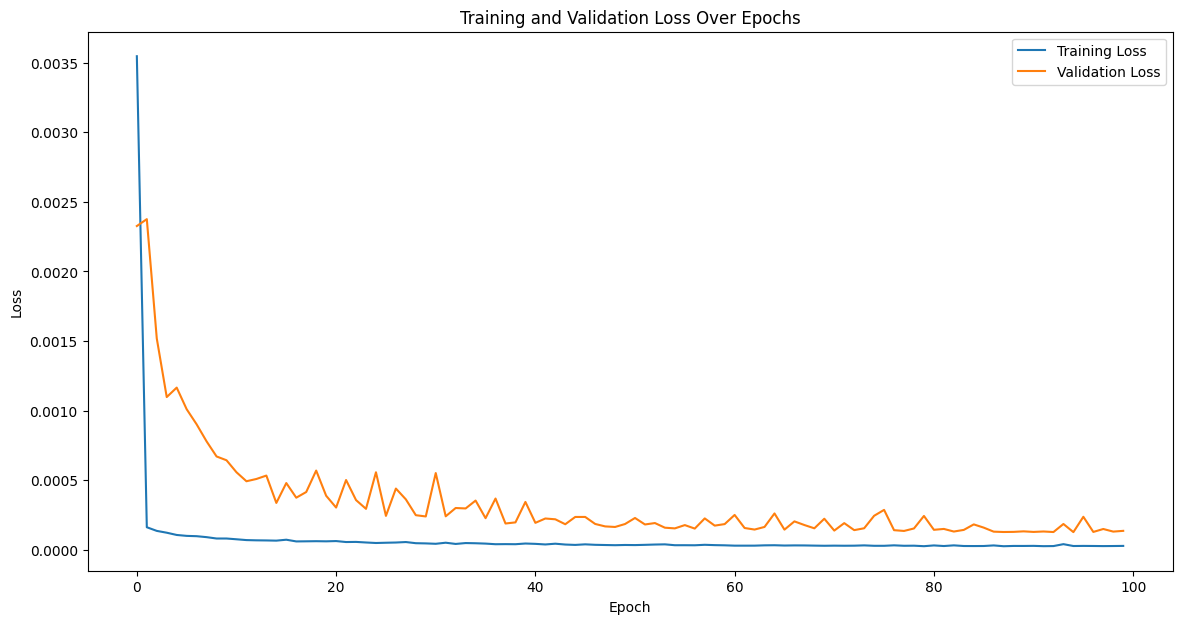

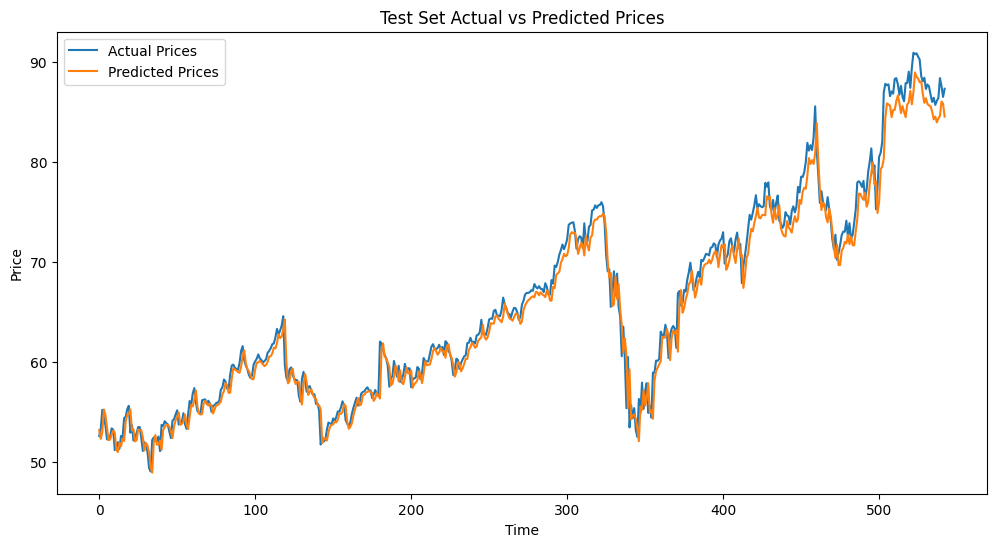

In [8]:

from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# download and prepare dataset
data = yf.download('GOOGL', start='2010-01-01', end='2021-01-01')
data = data[['Close']]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

# Create sequences and labels
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 60
x_data, y_data = create_sequences(scaled_data, SEQ_LENGTH)

# Split data into training, validation, and test sets
train_size = int(0.7 * len(x_data))
val_size = int(0.1 * len(x_data))
test_size = len(x_data) - train_size - val_size
x_train, x_val, x_test = x_data[:train_size], x_data[train_size:train_size+val_size], x_data[train_size+val_size:]
y_train, y_val, y_test = y_data[:train_size], y_data[train_size:train_size+val_size], y_data[train_size+val_size:]

# Define the basic RNN model using Keras
model = Sequential()
model.add(SimpleRNN(units=50, input_shape=(SEQ_LENGTH, 1)))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val))

# Evaluate on the test set
predicted = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

rmse_test = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f'Basic RNN Test Set RMSE: {rmse_test:.4f}')

# Plot the validation and training loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

# Plot the test results
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Test Set Actual vs Predicted Prices')
plt.legend()
plt.show()

####Part 2 (30 points):
Update your network from part 1 with first an LSTM and then a GRU
based cell structure (You can treat both as 2 separate implementations). Re-do the
training and performance evaluation. What are the major differences you notice? Why
do you think those differences exist between the 3 implementations (basic RNN, LSTM
and GRU)?

###Answer
Code and results are listed below. The performance differences among the basic RNN, LSTM, and GRU models, as indicated by their respective RMSE values (1.5277 for RNN, 1.2899 for LSTM, and 1.2975 for GRU), primarily stem from their distinct architectures and abilities to manage long-term dependencies. Basic RNNs, which inherently suffer from the vanishing gradient problem, typically focus on short-term dependencies. This limitation manifests in higher error rates as the model struggles to capture longer context required for accurate predictions in time series data like stock prices. The result is a less effective model compared to LSTM and GRU, particularly when the task demands preserving information over extended time steps.

In contrast, LSTMs and GRUs are engineered to handle long-range dependencies more adeptly, thanks to their specialized gating mechanisms. LSTMs, with their input, output, and forget gates, excel in maintaining memory over long sequences, which explains their superior performance and lowest RMSE of 1.2899. GRUs, while slightly less effective with an RMSE of 1.2975, offer a simplified architecture that balances computational efficiency and performance by merging certain gates, making them a viable alternative when resources are constrained. The choice between LSTM and GRU often hinges on the specific dataset characteristics and computational considerations, though both significantly outperform basic RNNs in tasks involving sequential dependencies.

In [5]:
!pip3 install keras

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0090 - val_loss: 0.0015
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.3115e-04 - val_loss: 5.7130e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.0574e-04 - val_loss: 6.1169e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.3955e-05 - val_loss: 5.2552e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.7104e-05 - val_loss: 4.7157e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 8.6161e-05 - val_loss: 4.4638e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.9819e-05 - val_loss: 4.2363e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.4816e-05 - val_loss: 4.1583e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.7224e-05 - val_loss: 4.2432e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.7716e-05 - val_loss: 4.5666e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.9861

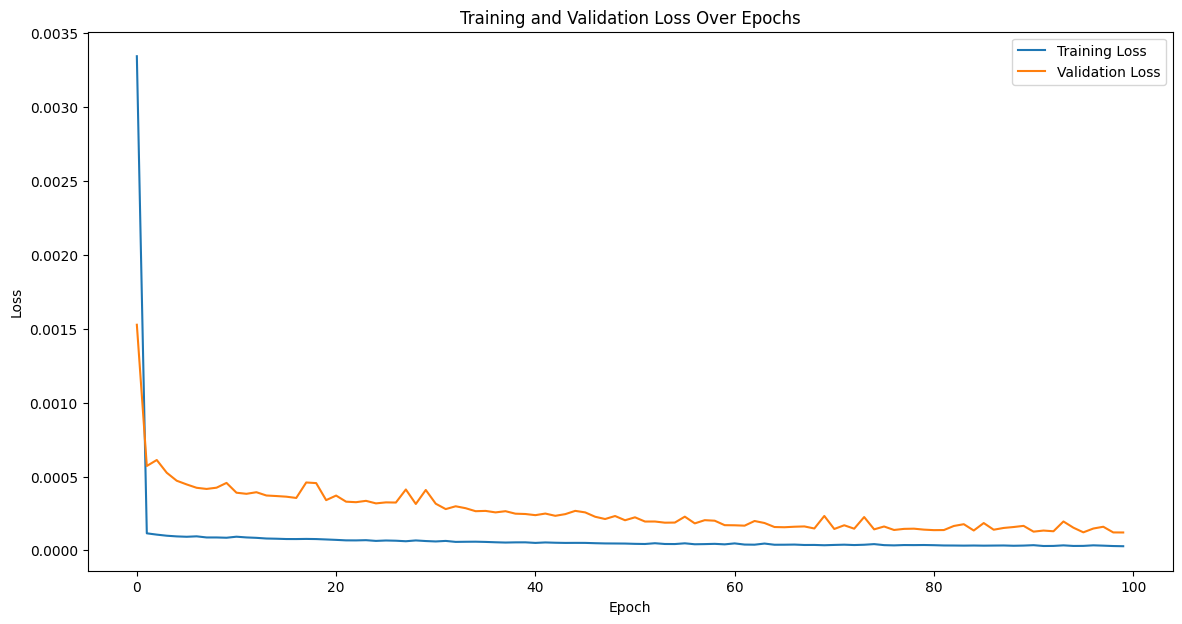

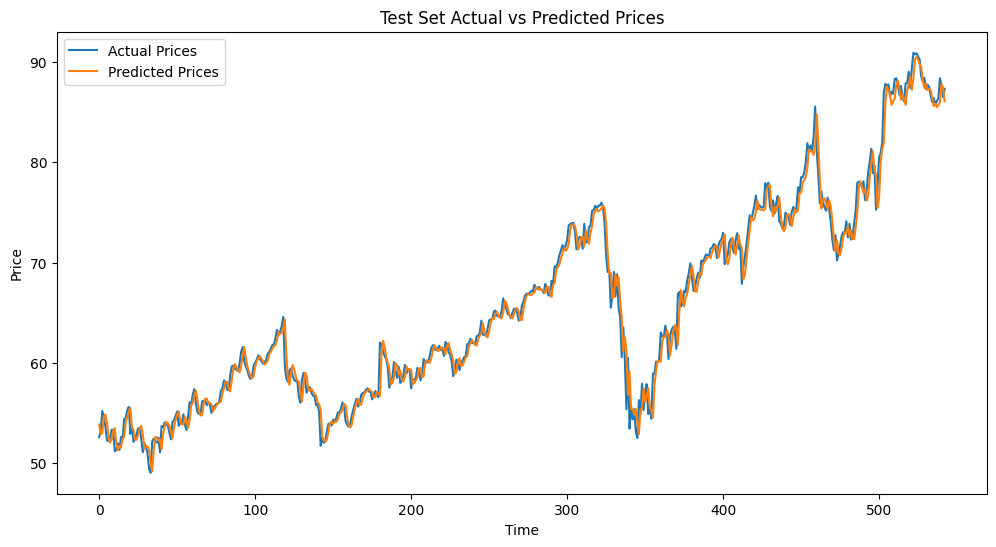

In [10]:
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# LSTM model using Keras
model = Sequential()
model.add(LSTM(units=50, input_shape=(SEQ_LENGTH, 1)))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val))

# Evaluate on the test set
predicted = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

rmse_test = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f'LSTM Test Set RMSE: {rmse_test:.4f}')

# Plot the validation and training loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

# Plot the test results
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Test Set Actual vs Predicted Prices')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                          │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0072 - val_loss: 3.6014e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5.2087e-05 - val_loss: 2.4747e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.8733e-05 - val_loss: 2.1572e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 4.2069e-05 - val_loss: 2.2050e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.7330e-05 - val_loss: 2.1117e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.8544e-05 - val_loss: 1.8832e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.9105e-05 - val_loss: 1.8136e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 3.3777e-05 - val_loss: 1.8043e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.4075e-05 - val_loss: 1.7322e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.2551e-05 - val_loss: 1.6691e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.

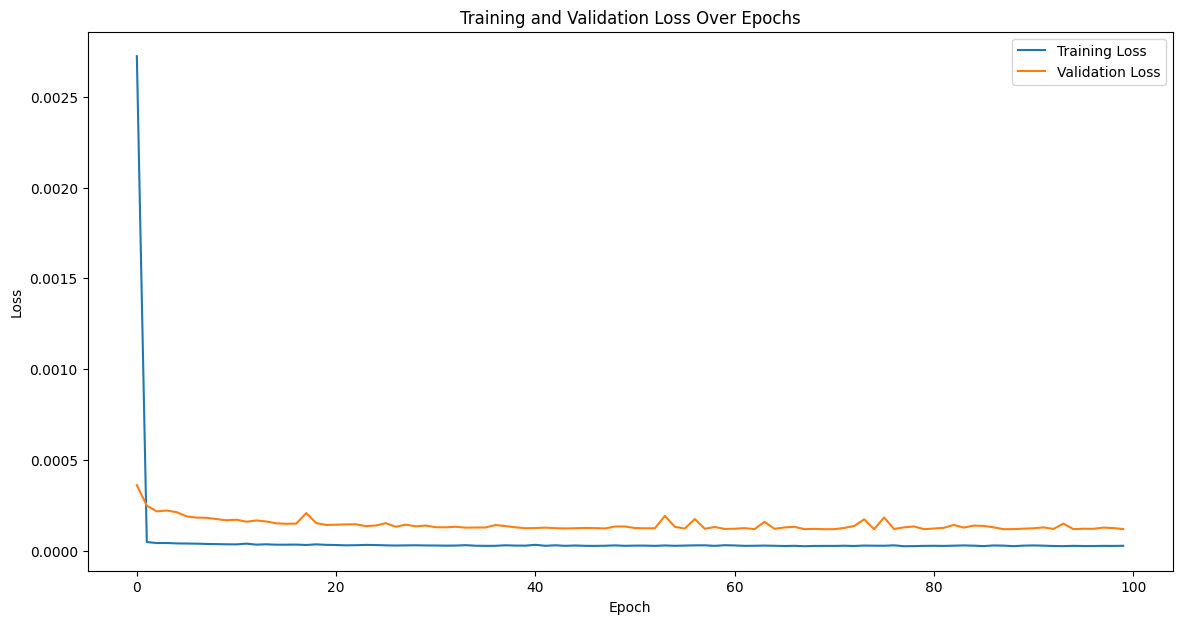

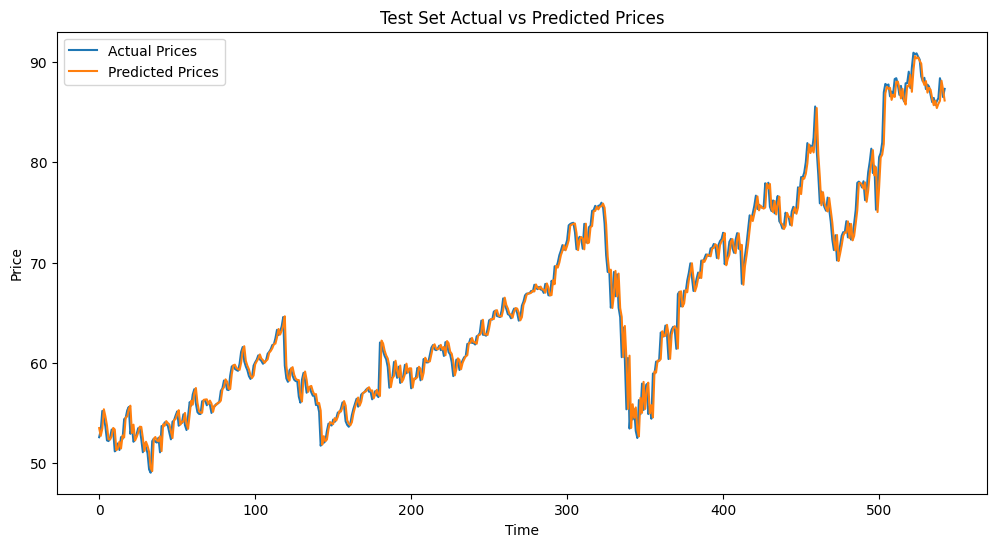

In [26]:
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# GRU model using Keras
model = Sequential()
model.add(GRU(units=50, input_shape=(SEQ_LENGTH, 1)))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val))

# Evaluate on the test set
predicted = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

rmse_test = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f'GRU Test Set RMSE: {rmse_test:.4f}')

# Plot the validation and training loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

# Plot the test results
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Test Set Actual vs Predicted Prices')
plt.legend()
plt.show()

####Part 3 (10 points):
Can you use the traditional feed-forward network to solve the same
problem. Why or why not? (Hint: Can time series data be converted to usual features
that can be used as input to a feed-forward network?)

###Answer
Yes, a traditional feed-forward network can be used to solve time series prediction problems by transforming the sequential data into a form that can be fed into such a network. Although feed-forward networks, unlike recurrent ones, are not inherently designed to handle sequences or temporal dependencies, time series data can indeed be converted into a suitable format through a process called feature engineering.

While this approach permits the application of feed-forward networks to time series problems, it lacks the natural ability of architectures like RNNs or LSTMs to inherently capture temporal dependencies and long-term patterns present in sequential data. Therefore, while feasible, feed-forward networks may not perform as well on time series tasks without careful feature engineering.

###Task 3 (50 points):

####Part 1: Implementing Word Embeddings (10 points)
- Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT
embeddings).
- Provide a comparative discussion on why you chose this embedding over others.
- Load embeddings efficiently (either from pre-trained vectors or using an NLP library like
Gensim, SpaCy, or Hugging Face).
- Allow dynamic user input of two words and output their respective embeddings.
- Handle cases where a word is out of vocabulary (OOV) and suggest ways to approximate
its embedding.

###Answer
Code implemented with FastText is below. FastText (Facebook AI) uses subword information, making it robust to OOV words and spelling variations. It could handle OOV words better due to its subword representation, unlike Word2Vec and GloVe. BERT is powerful but overkill for simple word similarity tasks.

In [11]:
!pip3 install gensim

In [12]:
import gensim.downloader as api

# Load pre-trained FastText embeddings (this takes time) use NLP library Gensim
fasttext_model = api.load("fasttext-wiki-news-subwords-300")


[==================================================] 100.0% 958.5/958.4MB downloaded


In [35]:
def get_word_embedding(word):
    if word in fasttext_model.key_to_index:
        return fasttext_model[word]
    else:
        # OOV words: FastText can still generate embeddings
        # via character n-grams even if the word isn't explicitly in the vocab.
        print(f"'{word}' is not in the vocabulary, generating embedding using subwords.")
        return get_approximate_embedding(word,fasttext_model)

# dynamic input
word1 = input("Enter first word: ").strip().lower()
word2 = input("Enter second word: ").strip().lower()

# Retrieve embeddings
embedding1 = get_word_embedding(word1)
embedding2 = get_word_embedding(word2)

print(f"Embedding for '{word1}':\n", embedding1[:10])
print(f"Embedding for '{word2}':\n", embedding2[:10])


Enter first word: harry
Enter second word: potter
Embedding for 'harry':
 [ 0.051754  -0.10355   -0.023611  -0.0037032 -0.023855  -0.0010239
 -0.034532  -0.14822    0.050171   0.090818 ]
Embedding for 'potter':
 [ 0.054217  -0.070086  -0.057689   0.0050352 -0.027069   0.037787
 -0.093267  -0.12262    0.049612   0.021475 ]


In [39]:
def get_approximate_embedding(word, model, n=3):
    subwords = [word[i:i+n] for i in range(len(word) - n + 1)]
    subword_embeddings = []

    for subword in subwords:
        if subword in model.key_to_index:
            subword_embeddings.append(model[subword])

    if subword_embeddings:
        return sum(subword_embeddings) / len(subword_embeddings)
    else:
        # Fallback if no subwords are in the vocab
        print(f"No subwords found for '{word}', initializing random embedding.")
        return np.random.rand(model.vector_size)
# test oov
oov_word = "textp"
embedding = get_word_embedding(oov_word)
print(embedding)

'textp' is not in the vocabulary, generating embedding using subwords.
[-0.023675   -0.0282765   0.074147    0.00153     0.01644835  0.0065195
  0.01148185 -0.13071999 -0.0850855  -0.200195   -0.00143255 -0.0688535
 -0.0290715  -0.01797025  0.0895225  -0.040836    0.065252    0.004966
  0.103956   -0.03685045  0.0735085   0.048303   -0.0025545   0.138842
  0.1535085  -0.008469   -0.053182    0.051373   -0.0279795  -0.0196055
 -0.00881165  0.100254    0.0479925  -0.063676    0.00845092 -0.013998
 -0.03192827 -0.047541    0.0357105   0.042711    0.01063455 -0.052091
 -0.0004995  -0.051436   -0.045461    0.005356   -0.004955   -0.073406
  0.01185     0.0408265   0.0153705   0.00155765  0.05100135 -0.0502825
 -0.01673375  0.052994   -0.128225    0.0335495  -0.041347   -0.006722
 -0.058255   -0.0186755   0.21109    -0.05297415  0.0509757   0.00375925
  0.0387345  -0.0534225   0.0693435  -0.0960885  -0.0409384  -0.143888
  0.0068245   0.0073945   0.038833   -0.05357935 -0.031774   -0.141788


####Part 2: Cosine Similarity Computation (20 points)
- Implement a function that computes the cosine similarity between two-word
embeddings.
- Explain why cosine similarity is useful in word embedding space.
- Allow batch processing, where users can input multiple word pairs for simultaneous
similarity computation.
- Visualization Requirement: Create a 2D or 3D scatter plot (e.g., using PCA or t-SNE) to
visually show how similar and dissimilar words cluster together in the embedding space.

###Answer
Cosine similarity measures the cosine of the angle between two non-zero vectors of an inner product space. It is a measure of how similar two vectors (in this case, word embeddings) are, independent of their magnitude. Cosine similarity is useful in word embedding space because it effectively captures semantic similarity: words that are used in similar contexts will have similar vector representations and a higher cosine similarity, while dissimilar words will have lower cosine similarity.

In [45]:
import numpy as np

def cosine_similarity(emb1, emb2):
    if emb1.ndim == 1:
        emb1 = emb1[np.newaxis, :]
    if emb2.ndim == 1:
        emb2 = emb2[np.newaxis, :]

    assert emb1.shape == emb2.shape, "Embeddings arrays must have the same shape."

    dot_product = np.sum(emb1 * emb2, axis=1)

    # Compute the L2 norms of each embedding
    norms1 = np.linalg.norm(emb1, axis=1)
    norms2 = np.linalg.norm(emb2, axis=1)

    return dot_product / (norms1 * norms2)

word1 = "first"
word2 = "inception"

embedding1 = get_word_embedding(word1)
embedding2 = get_word_embedding(word2)

similarity = cosine_similarity(embedding1, embedding2)
print(f"Cosine Similarity between '{word1}' and '{word2}':", similarity)

Cosine Similarity between 'first' and 'inception': [0.41813713]


Cosine Similarities:
Similarity between 'shark' and 'sparrow': 0.3758
Similarity between 'wolf' and 'giraffe': 0.4484
Similarity between 'penguin' and 'eagle': 0.4718
Similarity between 'rabbit' and 'rooster': 0.5148
Similarity between 'fish' and 'wolf': 0.4180
Similarity between 'deer' and 'horse': 0.5188
Similarity between 'giraffe' and 'fish': 0.3896
Similarity between 'elephant' and 'horse': 0.5822
Similarity between 'rabbit' and 'goat': 0.6161
Similarity between 'dolphin' and 'zebra': 0.4469


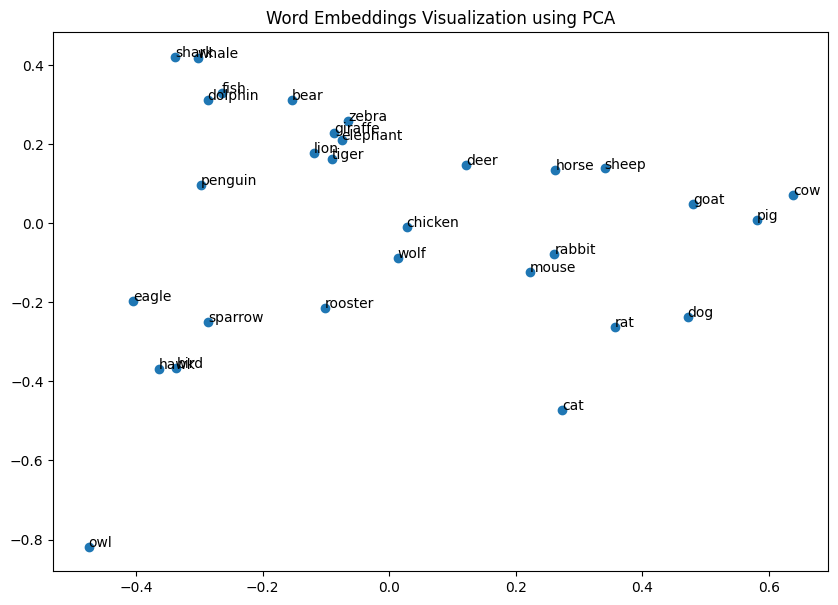

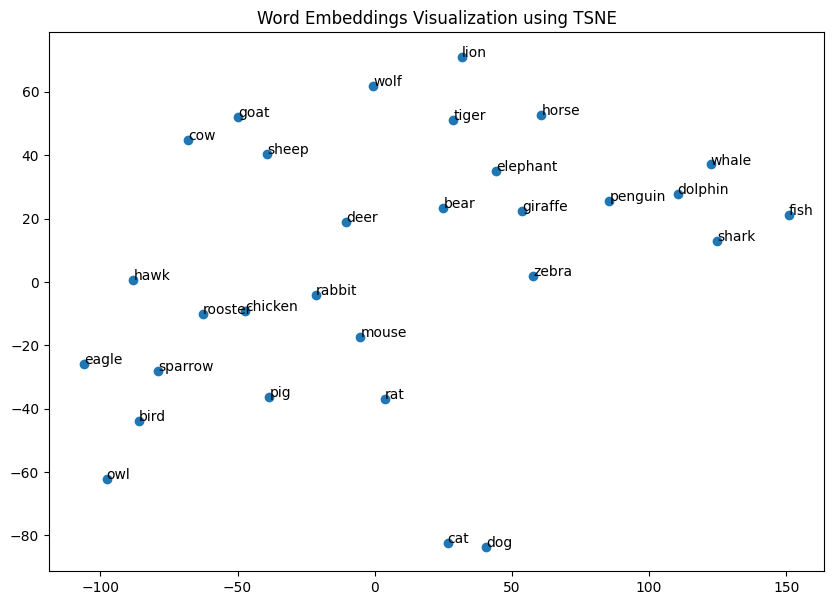

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

def visualize_embeddings(embeddings, labels, method='pca', dimensions=2):
    if method == 'pca':
        reducer = PCA(n_components=dimensions)
    elif method == 'tsne':
        reducer = TSNE(n_components=dimensions, perplexity=5)  # Set perplexity < number of samples
    else:
        raise ValueError("Method should be either 'pca' or 'tsne'")

    reduced_embeddings = reducer.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    if dimensions == 2:
        plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
        for i, label in enumerate(labels):
            plt.annotate(label, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))
    elif dimensions == 3:
        ax = plt.axes(projection='3d')
        ax.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], reduced_embeddings[:, 2])
        for i, label in enumerate(labels):
            ax.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], reduced_embeddings[i, 2], label)

    plt.title(f'Word Embeddings Visualization using {method.upper()}')
    plt.show()

words = [
    "cat", "fish", "dog", "bird", "horse", "cow", "pig", "sheep", "goat", "deer",
    "lion", "tiger", "bear", "wolf", "rabbit", "mouse", "rat", "elephant", "giraffe", "zebra",
    "owl", "hawk", "eagle", "sparrow", "chicken", "rooster", "penguin", "dolphin", "whale", "shark"
]


word_emds = {word: get_word_embedding(word) for word in words}

random.seed(0)  # For reproducibility
word_pairs = random.sample([(w1, w2) for w1 in words for w2 in words if w1 != w2], 10)

# Prepare data for cosine similarity computation
embeddings1 = np.array([word_emds[pair[0]] for pair in word_pairs])
embeddings2 = np.array([word_emds[pair[1]] for pair in word_pairs])

# Compute similarity for each pair
similarities = cosine_similarity(embeddings1, embeddings2)

# Output the similarities
print("Cosine Similarities:")
for pair, similarity in zip(word_pairs, similarities):
    print(f"Similarity between '{pair[0]}' and '{pair[1]}': {similarity:.4f}")

all_embeddings = np.array([word_emds[word] for word in words])
all_labels = words

# 2D and 3D
visualize_embeddings(all_embeddings, all_labels, method='pca', dimensions=2)
visualize_embeddings(all_embeddings, all_labels, method='tsne', dimensions=2)

####Part 3: Designing a Novel Dissimilarity Metric (20 points)
- Define a custom dissimilarity score that goes beyond cosine similarity. Possible
approaches include:
  - Euclidean distance (How far apart words are in vector space).
  - Word entropy-based dissimilarity (How uncommon two words are relative to
  each other in corpora).
  - Semantic contrast measure (Using external knowledge bases like WordNet).
- Either design your own metric or cite an existing one from literature (provide a proper reference).
  Explain why your metric captures novelty/diversity better than cosine
  similarity alone.
- Allow users to toggle between different similarity/dissimilarity measures via function
parameters.
- Visualization Requirement:
  - Plot the ranking of words based on their similarity/dissimilarity to a given word
  (e.g., how words like "cat" rank against "dog," "lion," and "table" using different
  metrics).
  - Use a heatmap to demonstrate and compare similarity and dissimilarity across
  multiple (any number of your choice) word pairs.

###Answer
The Semantic Entropy Dissimilarity (SED) is a novel metric designed to capture the dissimilarity between words by integrating word entropy and semantic contrast measures. This metric offers a nuanced understanding of word relationships by considering both the relative uncommonness of words and their semantic differences as determined by resources like WordNet. The component of word entropy-based dissimilarity calculates the entropy of a word based on its frequency in a large corpus, with higher entropy indicating greater commonality and lower informativeness. Specifically, the entropy of a word $w$ is calculated as:

$$
H(w) = -\sum_{i=1}^{n} P(w_i) \log_2 P(w_i)
$$

where $P(w_i)$ represents the probability of occurrence of word $w_i$ in the corpus. In parallel, the semantic contrast measure utilizes WordNet to examine the semantic differences between two words by computing and normalizing their path length in the WordNet hierarchy.

In combining these components, SED offers a comprehensive metric, computed as:

$$
\text{SED}(a, b) = \alpha \cdot (H(a) + H(b)) + \beta \cdot \text{semantic\_contrast}(a, b)
$$

where $\alpha$ and $\beta$ are adjustable parameters that allow users to balance the emphasis on entropy versus semantic contrast. This metric captures novelty and diversity more effectively than cosine similarity, as it is sensitive to the rarity and informativeness of words, providing insights into whether words are novel or typical. Furthermore, SED's semantic awareness, derived from WordNet, enables it to recognize deeper relationships and semantic contrasts between words beyond simple syntactic coherence. This integration permits users to switch between cosine similarity and SED through configurable function parameters, enhancing flexibility in analyzing word relationships.

In [59]:
!pip3 install nltk

[nltk_data] Downloading package wordnet to /root/nltk_data...


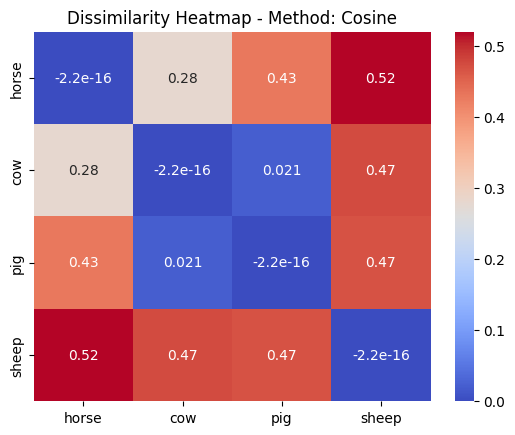

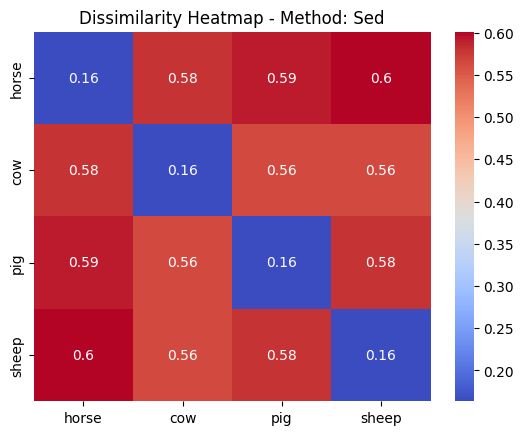

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import wordnet as wn

nltk.download('wordnet')

def calculate_entropy(word, corpus):
    probability = corpus.count(word) / len(corpus)
    return -probability * np.log2(probability) if probability > 0 else 0

def semantic_contrast(a, b):
    a_synsets = wn.synsets(a)
    b_synsets = wn.synsets(b)
    if not a_synsets or not b_synsets:
        return 1

    max_contrast = max(wn.path_similarity(a_s, b_s) or 0 for a_s in a_synsets for b_s in b_synsets)
    return 1 - max_contrast

def semantic_entropy_dissimilarity(a, b, corpus, alpha=0.5, beta=0.5):
    entropy_a = calculate_entropy(a, corpus)
    entropy_b = calculate_entropy(b, corpus)
    semantic_contrast_val = semantic_contrast(a, b)
    return alpha * (entropy_a + entropy_b) + beta * semantic_contrast_val

def calculate_cosine_similarity(vec_a, vec_b):
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot_product / (norm_a * norm_b)

def calculate_dissimilarities(target_word, words, vectors, corpus, method='cosine'):
    dissimilarities = {}
    target_vector = vectors[target_word]

    for word in words:
        if method == 'cosine':
            sim = calculate_cosine_similarity(target_vector, vectors[word])
            dissimilarities[word] = 1 - sim  # Dissimilarity as 1 - similarity
        elif method == 'sed':
            dissimilarities[word] = semantic_entropy_dissimilarity(target_word, word, corpus)

    return dissimilarities

def plot_heatmap(words, vectors, corpus, method='cosine'):
    dissimilarities_matrix = []

    for key_word in words:
        dissimilarities = calculate_dissimilarities(key_word, words, vectors, corpus, method)
        row = [dissimilarities[word] for word in words]
        dissimilarities_matrix.append(row)

    sns.heatmap(dissimilarities_matrix, annot=True, cmap='coolwarm', xticklabels=words, yticklabels=words)
    plt.title(f'Dissimilarity Heatmap - Method: {method.capitalize()}')
    plt.show()

corpus = [
    "cat", "fish", "dog", "bird", "horse", "cow", "pig", "sheep", "goat", "deer",
    "lion", "tiger", "bear", "wolf", "rabbit", "mouse", "rat", "elephant", "giraffe", "zebra",
    "owl", "hawk", "eagle", "sparrow", "chicken", "rooster", "penguin", "dolphin", "whale", "shark"
]

words = ["horse", "cow", "pig", "sheep"]

# Generate word embeddings
word_emds = {word: get_word_embedding(word) for word in words}

# Visualization
plot_heatmap(words, word_emds, corpus, method='cosine')
plot_heatmap(words, word_emds, corpus, method='sed')